In [1]:
# Import necessary libraries 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from open_ephys.analysis import Session
import scipy.signal as signal
try:
    from numpy import trapezoid as trapz   # NumPy >= 2.0
except ImportError:
    from numpy import trapz                # NumPy < 2.0 fallback
from scipy.stats import sem
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.signal import iirnotch, filtfilt, butter, hilbert
import matplotlib.lines as mlines
from scipy.stats import linregress, spearmanr

# Load the session (route to session folder directory)
directory = 'eegpr6-3-13-26'
session = Session(directory)

In [2]:
# Access first record node and recording (may vary across sessions)
record_node = session.recordnodes[0]    #0 is 101, RAW. #1 is 106, FILTERED
print(record_node)
# Load specific recording
recording = session.recordnodes[0].recordings[0]

# Extract metadata and global timestamps
metadata = recording.continuous[0].metadata
channel_names = metadata.channel_names
timestamps = recording.continuous[0].timestamps
samplerate = metadata.sample_rate
print(f"Samplerate: {samplerate} Hz")   # Should be 5000Hz

# Check Timestamps, should be in seconds, increments of 0.0002 per sample, sampling rate of 5000 Hz
print(timestamps[:10])
print(np.diff(timestamps[:10])[:5])

data = recording.continuous[0].get_samples(start_sample_index=0, end_sample_index=timestamps.shape[0])
print("Data shape:", data.shape)

# Filter sync events for Line 1
events = recording.events

# SHAM TRIALS 
sham_events = events[
    (events.line == 1) &
    (events.processor_id == 100) &
    (events.stream_name == 'Rhythm Data') &
    (events.state == 1)
]
sham_timestamps = sham_events['timestamp'].to_numpy()

# VNS TRIALS 
vns_events = events[
    (events.line == 3) &
    (events.processor_id == 100) &
    (events.stream_name == 'Rhythm Data') &
    (events.state == 1)
]
vns_timestamps = vns_events['timestamp'].to_numpy()

# Load MessageCenter files, may vary across sessions
messagecenter_dir = os.path.join(directory, "Record Node 101", "experiment1", "recording1", "events", "MessageCenter")
texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
sample_numbers = np.load(os.path.join(messagecenter_dir, "sample_numbers.npy"))

# Decode message texts
decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]

# Debug print
print(f"Loaded {len(decoded_texts)} MessageCenter entries")
for text, time in zip(decoded_texts, timestamps_msg):
    print(f"[Time: {time:.6f} s] Message: {text}")
print("Unique TTL lines:", np.unique(events.line))
print("Total events:", len(events))
print("VNS count:", len(vns_timestamps))
print("Sham count:", len(sham_timestamps))

Record Node 101 (binary format)
Samplerate: 5000.0 Hz
[0.6882 0.6884 0.6886 0.6888 0.689  0.6892 0.6894 0.6896 0.6898 0.69  ]
[0.0002 0.0002 0.0002 0.0002 0.0002]
Data shape: (15014694, 9)
Loaded 0 MessageCenter entries
Unique TTL lines: [1 3]
Total events: 398
VNS count: 98
Sham count: 101


In [3]:
# Common reference subtraction for channels EEG - 3. 
# Reference is Channel 4, since it is at the back of the head

# Data Shape is (X, 9) where columns are as follows: (VARIES BASED ON RAT)
# 0: None
# 1: EEG 
# 2: Electrode 1
# 3: Electrode 2 
# 4: Electrode 3
# 5: Electrode 4 (common reference)
# 6: ADC1
# 7: ADC2
# 8: ADC3

ref = data[:, 5]    # Set electrode 4 as reference
target = data[:, 1:5] # Target is EEG, Electrode 1-3, indexing rules slice end (5) is exclusive)

# Subtract reference from target channels, and store in new variable data_diff to preserev original data
# data_diff is what will be used for all subsequent analyses, and data will be preserved in case we want to look at it later without reference subtraction
data_difference = target - ref[:, None]
data_diff = data
data_diff[:, 1:5] = data_difference
print(data_diff.shape)

(15014694, 9)


In [4]:
# PREPROCESSING: FILTERING & DECIMATION-----
# (a) High-pass filter to remove slow drift (e.g., below 0.5 Hz)  Low pass > 
# Before low pass do 50-60-280-140~usually 2x higher than low pass Hz notch filter
# 
hp_cutoff = 0.5  # Cutoff frequency (in Hz)

# 4th order Butterworth high-pass filter, 4 = filter order, normalized cutoff frequency (cutoff frequency divided by Nyquist frequency)
b_hp, a_hp = signal.butter(4, hp_cutoff / (samplerate / 2), btype='high')   

print(data_diff.shape)
'''
Parameters for notch filter:
- x: input signal (data)
- fs: sampling frequency (samplerate)
- freq: frequency to be removed (default 60 Hz)
- quality_factor: quality factor for the notch filter (default 30)
- axis: axis along which to apply the filter (default 0, which is time)
'''
def notch_filter(x, fs, freq=60, quality_factor=30, axis=0):
    b, a = iirnotch(freq / (fs / 2), quality_factor)
    return filtfilt(b, a, x, axis=axis)

# Run notch filter first to remove 60 Hz noise, then apply high-pass filter to remove slow drift
data_diff = notch_filter(data_diff, samplerate, axis=0)   # filter across time
data_diff = signal.filtfilt(b_hp, a_hp, data_diff, axis=0)

print(data_diff.shape)
print("time length:", data_diff.shape[0], "channels:", data_diff.shape[1])


(15014694, 9)
(15014694, 9)
time length: 15014694 channels: 9


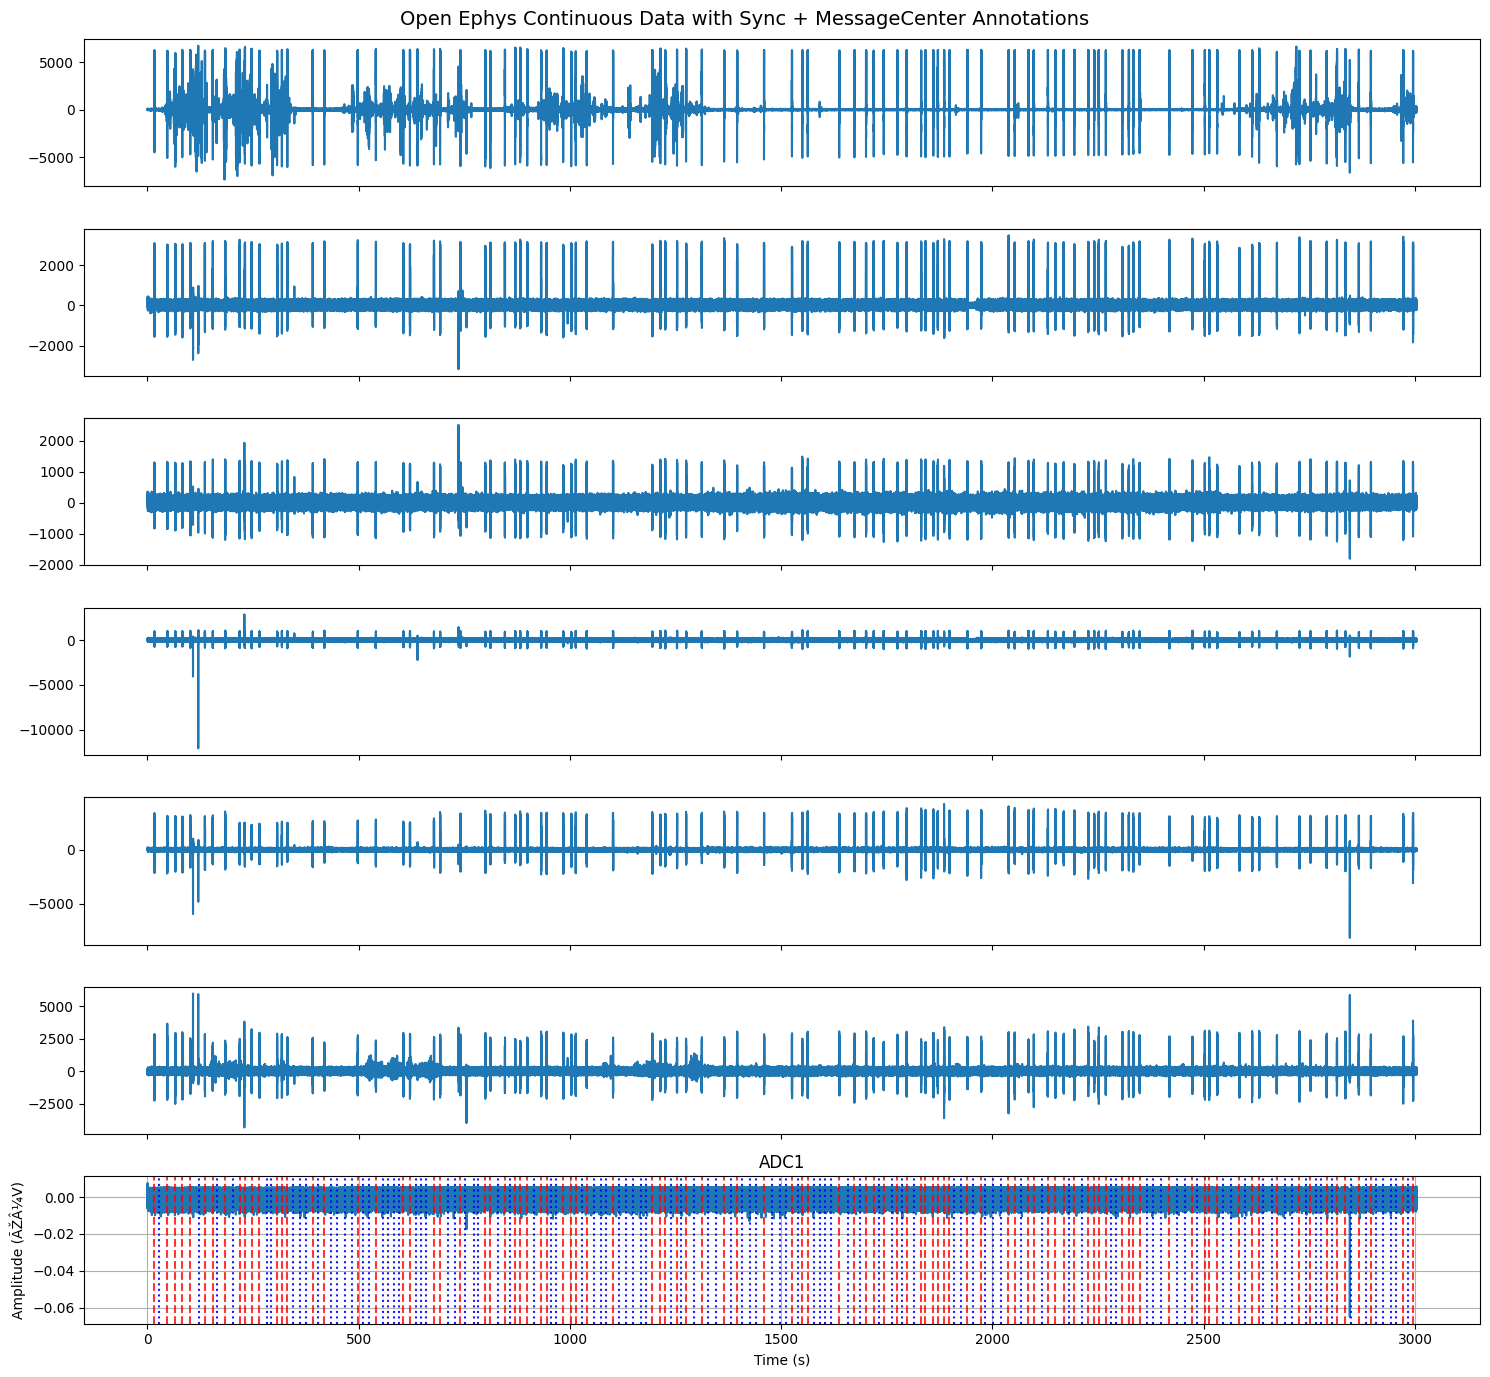

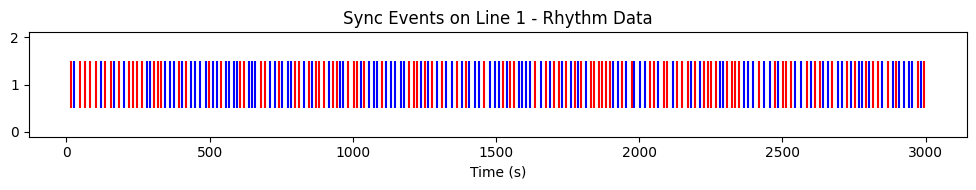

In [5]:
# Plot continuous data of entire session
num_channels_to_plot = len(channel_names) - 2

fig, axes = plt.subplots(num_channels_to_plot, 1,
                         figsize=(15, 2 * num_channels_to_plot),
                         sharex=True)

for idx, ax in enumerate(axes):
    ax.plot(timestamps, data_diff[:, idx], label=channel_names[idx])

# Plot VNS 
for t in vns_timestamps:
    ax.axvline(x=t, color='red', linestyle='--', alpha=0.8,
               label='VNS' if t == vns_timestamps[0] else "")
# Plot Sham
for t in sham_timestamps:
    ax.axvline(x=t, color='blue', linestyle=':', alpha=0.9,
               label='Sham' if t == sham_timestamps[0] else "")
    
    ax.set_ylabel('Amplitude (ÃŽÂ¼V)')
    ax.set_title(channel_names[idx])
    ax.grid(True)
    if idx == 0:  # Only annotate messages on topmost plot (Ch5)
        for time, msg in zip(timestamps_msg, decoded_texts):
            ax.axvline(x=time, color='green', linestyle='--', alpha=0.6)
            ax.annotate(
                msg,
                xy=(time, ax.get_ylim()[1]),
                xytext=(time + 0.1, ax.get_ylim()[1] * 1.05),
                rotation=30,  # angled, not vertical
                fontsize=9,
                color='green',
                arrowprops=dict(arrowstyle='->', color='green', lw=1),
                ha='left'
            )

axes[-1].set_xlabel('Time (s)')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Leave space at top
plt.suptitle('Open Ephys Continuous Data with Sync + MessageCenter Annotations', fontsize=14)
plt.show()

# Optional: standalone sync event plot
plt.figure(figsize=(10, 2))
plt.eventplot(vns_timestamps, orientation='horizontal', colors='red')
plt.eventplot(sham_timestamps, orientation='horizontal', colors='blue')
plt.title(f'Sync Events on Line 1 - Rhythm Data')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [6]:
# Combine VNS/SHAM timestamps into single array 
all_stim_timestamps = np.concatenate((vns_timestamps, sham_timestamps))
# Same as above, but creates labels for each event instead of timestamps
stim_labels = np.concatenate((
    np.full(len(vns_timestamps), 'VNS'),
    np.full(len(sham_timestamps), 'SHAM')
))

# Sort VNS/SHAM timestamps by time to ensure correct order
sort_idx = np.argsort(all_stim_timestamps)
all_stim_timestamps = all_stim_timestamps[sort_idx]
stim_labels = stim_labels[sort_idx]

# Create a trial table for reference and use in later analysis
# (1,3) = (# in array, 1: Trial #, 2: VNS/SHAM Label, 3: Timestamp)
trial_numbers = np.arange(1, len(all_stim_timestamps)+1)
trial_table = pd.DataFrame({
    'Trial': trial_numbers,
    'Type': stim_labels,
    'Timestamp': all_stim_timestamps
})

pre_time = 5 # seconds before event
post_time = 15 # seconds after event
stimulation_duration = 1 # seconds, duration of VNS pulse
eeg_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta":  (13, 30),
    "Gamma": (30, 50),
}

# Choose nperseg so that the window length (in samples) is appropriate for the decimated data.
nperseg = int(samplerate)

In [7]:
# Function to extract windowed data for given trial table
# Takes in data from a trial (data is within window) and calculates 
def extract_windows(trial_table, timestamps, data):
    windows = []    # Python list to hold windowed data for each trial

    for idx, row in trial_table.iterrows():
        event_time = row['Timestamp']       # Start time of event(stimulation)
        start_time = event_time - pre_time  # Start time of stim window (before event AKA pretime)
        end_time = event_time + post_time   # End time of stim window
        mask = (timestamps >= start_time) & (timestamps <= end_time)    # Create mask w/start and end times
        window_data = data[mask, :] # Creates window of eeg data based on ^^^^
        window_timestamps = timestamps[mask] - event_time  # Creates window of timestamps based on ^^^

        # Split into pre and post stimulation data
        pre_mask = window_timestamps < 0
        post_mask = window_timestamps >= stimulation_duration # Exclude stim period 
        pre_data = window_data[pre_mask, :]
        post_data = window_data[post_mask, :]
        pre_timestamps = window_timestamps[pre_mask]
        post_timestamps = window_timestamps[post_mask]

        windows.append({
            'trial': row['Trial'],
            'type': row['Type'],
            'data': window_data,
            'timestamps': window_timestamps,
            'pre_data': pre_data,
            'pre_timestamps': pre_timestamps,
            'post_data': post_data,
            'post_timestamps': post_timestamps,
            # Prepare dictionaries to store band power values and PSDs.
            # eeg_bands.keys() gets all keys from eeg_bands AKA frequencies
            'psds': [],
            'pre_psds': [],
            'post_psds': [],
            # Add mean/sem powers
            'pre_band_mean': {},
            'pre_band_sem': {},
            'post_band_mean': {},
            'post_band_sem': {}
        })
    return windows

# Create a nested dictionary of all trials with pre and post stimulation windows, and empty lists for storing PSD and band power values
all_trials = extract_windows(trial_table, timestamps, data_diff) 

In [8]:
# Calculate PSD and band power for each trial, pre and post stimulation windows, and store in trial dict
for trial in all_trials:
    for phase in ("pre", "post"):
        d = trial[f"{phase}_data"]    # (N_time, N_channels)
        trial[f"{phase}_freqs"] = []
        trial[f"{phase}_psd"] = []
        trial[f"{phase}_band_power"] = []   # Single scalar value of band power for each trial
        
        # Loop through channels and compute psd/band power for each channel
        for ch_idx in range(d.shape[1]):   # loop through channels
            ch = d[:, ch_idx]
            freqs, psd = signal.welch(ch,
                                      fs=samplerate,
                                      nperseg=nperseg,
                                      detrend="constant")

            trial[f"{phase}_freqs"].append(freqs)
            trial[f"{phase}_psd"].append(psd)

            band_power = {}
            for band, (low, high) in eeg_bands.items():
                idx = np.logical_and(freqs >= low, freqs <= high)
                band_power[band] = trapz(psd[idx], freqs[idx])
            trial[f"{phase}_band_power"].append(band_power)

    # Compute mean and SEM across channels for each band and phase
    for phase in ("pre", "post"):
        ch_band_powers = trial[f"{phase}_band_power"]
        trial[f"{phase}_band_mean"] = {}
        trial[f"{phase}_band_sem"] = {}
        for band in eeg_bands:
            vals = np.array([c[band] for c in ch_band_powers], dtype=float)
            trial[f"{phase}_band_mean"][band] = np.mean(vals)
            trial[f"{phase}_band_sem"][band] = sem(vals, ddof=0, nan_policy='omit')

    # optional full window var 
    all_data = np.vstack([trial["pre_data"], trial["post_data"]])
    freqs_all, psd_all = signal.welch(all_data[:, 0], fs=samplerate, nperseg=nperseg, detrend="constant")
    trial["freqs"] = freqs_all
    trial["psd"] = psd_all
    trial["power"] = {}
    for band, (low, high) in eeg_bands.items():
        bidx = np.logical_and(freqs_all >= low, freqs_all <= high)
        trial["power"][band] = trapz(psd_all[bidx], freqs_all[bidx])

In [9]:
# Seperate all_trials dictionary into VNS and SHAM lists 
std_trials = [trial for trial in all_trials if trial['type'] == 'VNS']
sham_trials = [trial for trial in all_trials if trial['type'] == 'SHAM']
# Print dictionary to ensure all our data is there and in the right format
# Band powers are stored in {phase}_band_power as a list of dictionaries, one per channel
trial0 = all_trials[2]
print("Trial fields:", list(trial0.keys()))
print("Trial:", trial0["trial"], "Type:", trial0["type"])
print("Data:", trial0["data"].shape)
print("Pre:", trial0["pre_data"].shape, "Post:", trial0["post_data"].shape)
print("Pre psd count:", len(trial0["pre_psds"]), "Post psd count:", len(trial0["post_psds"]))
print("Band means (pre):", trial0["pre_band_mean"], "Band SEMs (pre):", trial0["pre_band_sem"])
print("Band means (post):", trial0["post_band_mean"], "Band SEMs (post):", trial0["post_band_sem"])


Trial fields: ['trial', 'type', 'data', 'timestamps', 'pre_data', 'pre_timestamps', 'post_data', 'post_timestamps', 'psds', 'pre_psds', 'post_psds', 'pre_band_mean', 'pre_band_sem', 'post_band_mean', 'post_band_sem', 'pre_freqs', 'pre_psd', 'pre_band_power', 'post_freqs', 'post_psd', 'post_band_power', 'freqs', 'psd', 'power']
Trial: 3 Type: VNS
Data: (100001, 9)
Pre: (25001, 9) Post: (70000, 9)
Pre psd count: 0 Post psd count: 0
Band means (pre): {'Delta': np.float64(3569.3286878144136), 'Theta': np.float64(1864.2409561896097), 'Alpha': np.float64(1943.032892343469), 'Beta': np.float64(447.75984231784855), 'Gamma': np.float64(139.00395377096478)} Band SEMs (pre): {'Delta': np.float64(3331.82035678021), 'Theta': np.float64(1593.6675263393001), 'Alpha': np.float64(1650.038527658805), 'Beta': np.float64(294.5660162852501), 'Gamma': np.float64(42.73540111130103)}
Band means (post): {'Delta': np.float64(6321.6045910086605), 'Theta': np.float64(2081.285666314556), 'Alpha': np.float64(805.16

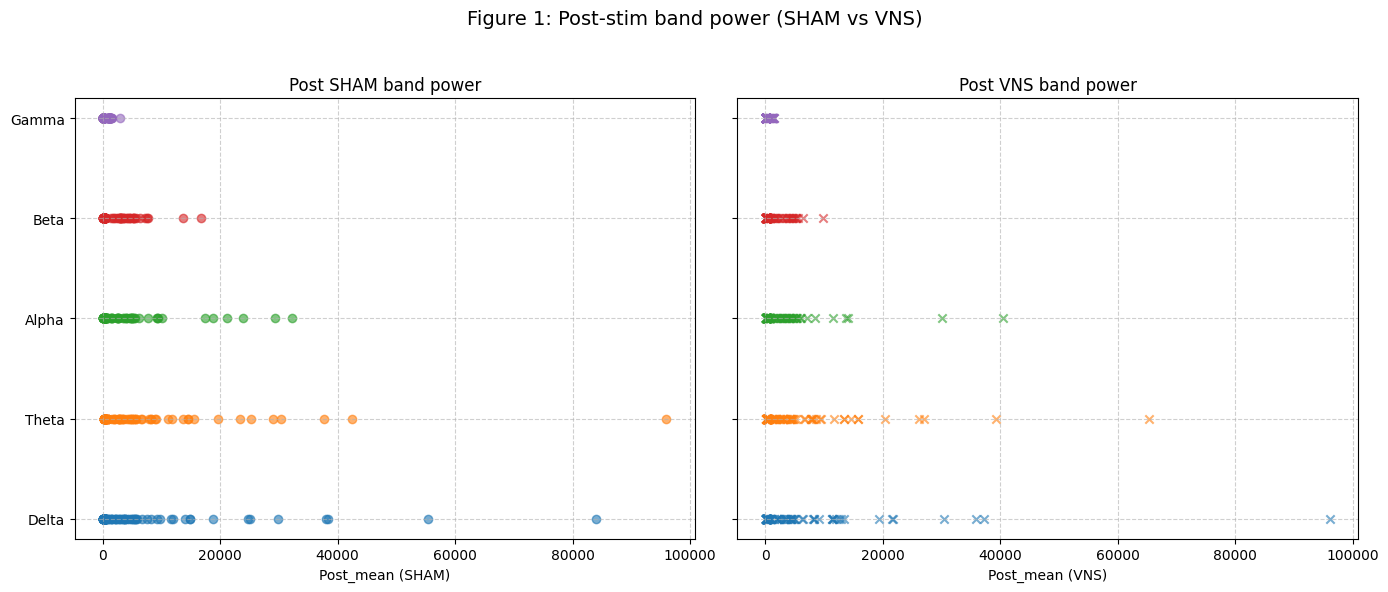

In [10]:
# -----------------------------
# Figure 1: Scatter Plot for each frequency
# -----------------------------

# Extract nested dictionary, all_trials and create a dictionary for plotting
plot_data = []
for t in all_trials:
    for band in eeg_bands:
        plot_data.append({
            "trial": t["trial"],
            "type": t["type"],          # 'VNS' or 'SHAM'
            "band": band,               # Delta/Theta/Alpha/Beta/Gamma
            "pre_mean": t["pre_band_mean"][band],
            "post_mean": t["post_band_mean"][band],
            "pre_sem": t["pre_band_sem"][band],
            "post_sem": t["post_band_sem"][band],
        })
df_power = pd.DataFrame(plot_data)  # Convert list of dicts to dataframe

# Build dictionary for post-stim power values for each band and type (VNS vs SHAM)
# Find rows where type = 'SHAM' and band = current band and grab the values
post_sham_power = {
    band: df_power.loc[(df_power["type"] == "SHAM") & (df_power["band"] == band), "post_mean"].values
    for band in eeg_bands
}
post_vns_power = {
    band: df_power.loc[(df_power["type"] == "VNS") & (df_power["band"] == band), "post_mean"].values
    for band in eeg_bands
}

# Initialize plot - share both axes so SHAM and VNS are directly comparable
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# SHAM
ax = axes[0]
for i, (band, values) in enumerate(post_sham_power.items()):
    ax.scatter(values, [i] * len(values), alpha=0.6, label=band)
ax.set_title("Post SHAM band power")
ax.set_yticks(range(len(post_sham_power)))
ax.set_yticklabels(list(post_sham_power.keys()))
ax.set_xlabel("Post_mean (SHAM)")
ax.grid(linestyle="--", alpha=0.6)

# VNS
ax = axes[1]
for i, (band, values) in enumerate(post_vns_power.items()):
    ax.scatter(values, [i] * len(values), alpha=0.6, label=band, marker="x")
ax.set_title("Post VNS band power")
ax.set_yticks(range(len(post_vns_power)))
ax.set_yticklabels(list(post_vns_power.keys()))
ax.set_xlabel("Post_mean (VNS)")
ax.grid(linestyle="--", alpha=0.6)

fig.suptitle("Figure 1: Post-stim band power (SHAM vs VNS)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

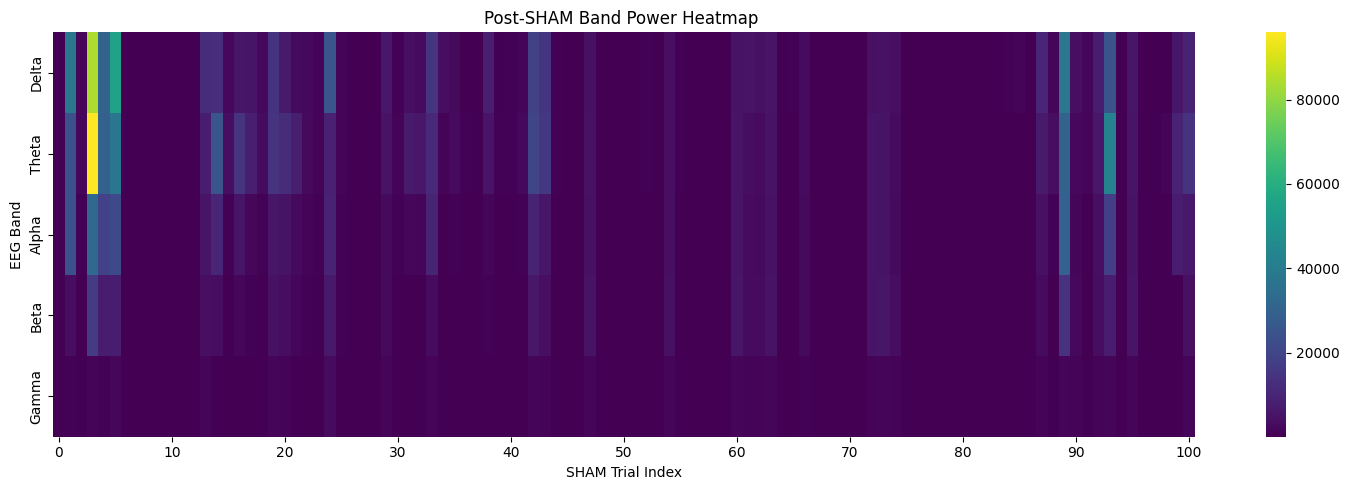

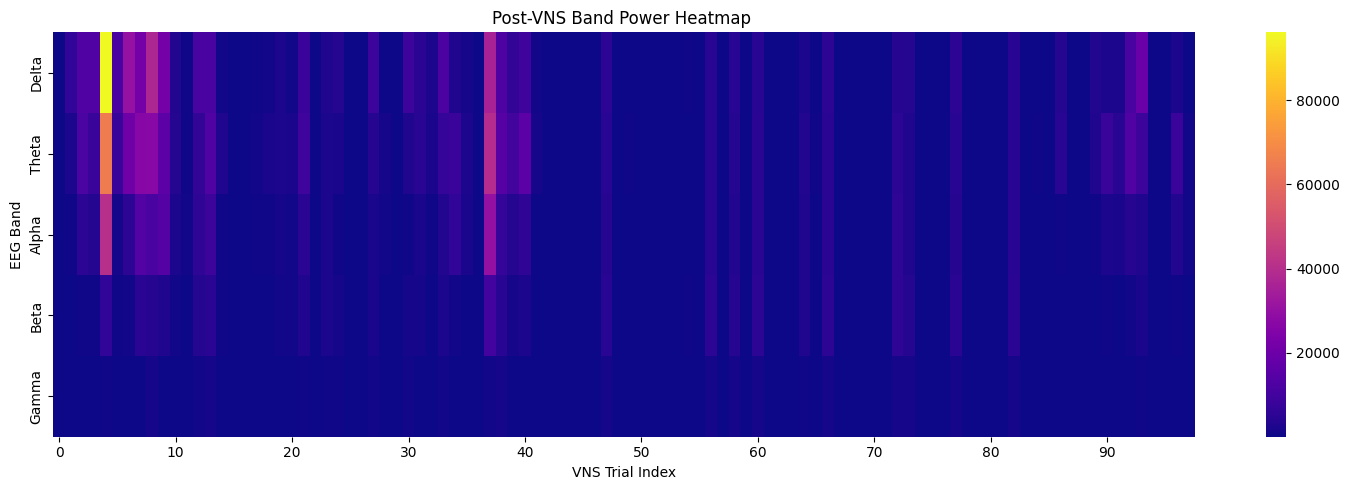

In [11]:
# -----------------------------
# Figure 2a: SHAM heatmap
# -----------------------------
heatmap_sham = np.array(list(post_sham_power.values()))  # shape (n_bands, n_sham_trials)

fig2a, ax2a = plt.subplots(figsize=(15, 5))
sns.heatmap(heatmap_sham,
            cmap="viridis",
            xticklabels=10,
            yticklabels=list(post_sham_power.keys()),
            ax=ax2a)
ax2a.set_xlabel("SHAM Trial Index")
ax2a.set_ylabel("EEG Band")
ax2a.set_title("Post-SHAM Band Power Heatmap ")

plt.tight_layout()
plt.show(block=False)

# -----------------------------
# Figure 2b: VNS heatmap
# -----------------------------
heatmap_vns = np.array(list(post_vns_power.values()))   # shape (n_bands, n_vns_trials)

fig2b, ax2b = plt.subplots(figsize=(15, 5))
sns.heatmap(heatmap_vns,
            cmap="plasma",
            xticklabels=10,
            yticklabels=list(post_vns_power.keys()),
            ax=ax2b)
ax2b.set_xlabel("VNS Trial Index")
ax2b.set_ylabel("EEG Band")
ax2b.set_title("Post-VNS Band Power Heatmap ")

plt.tight_layout()
plt.show()

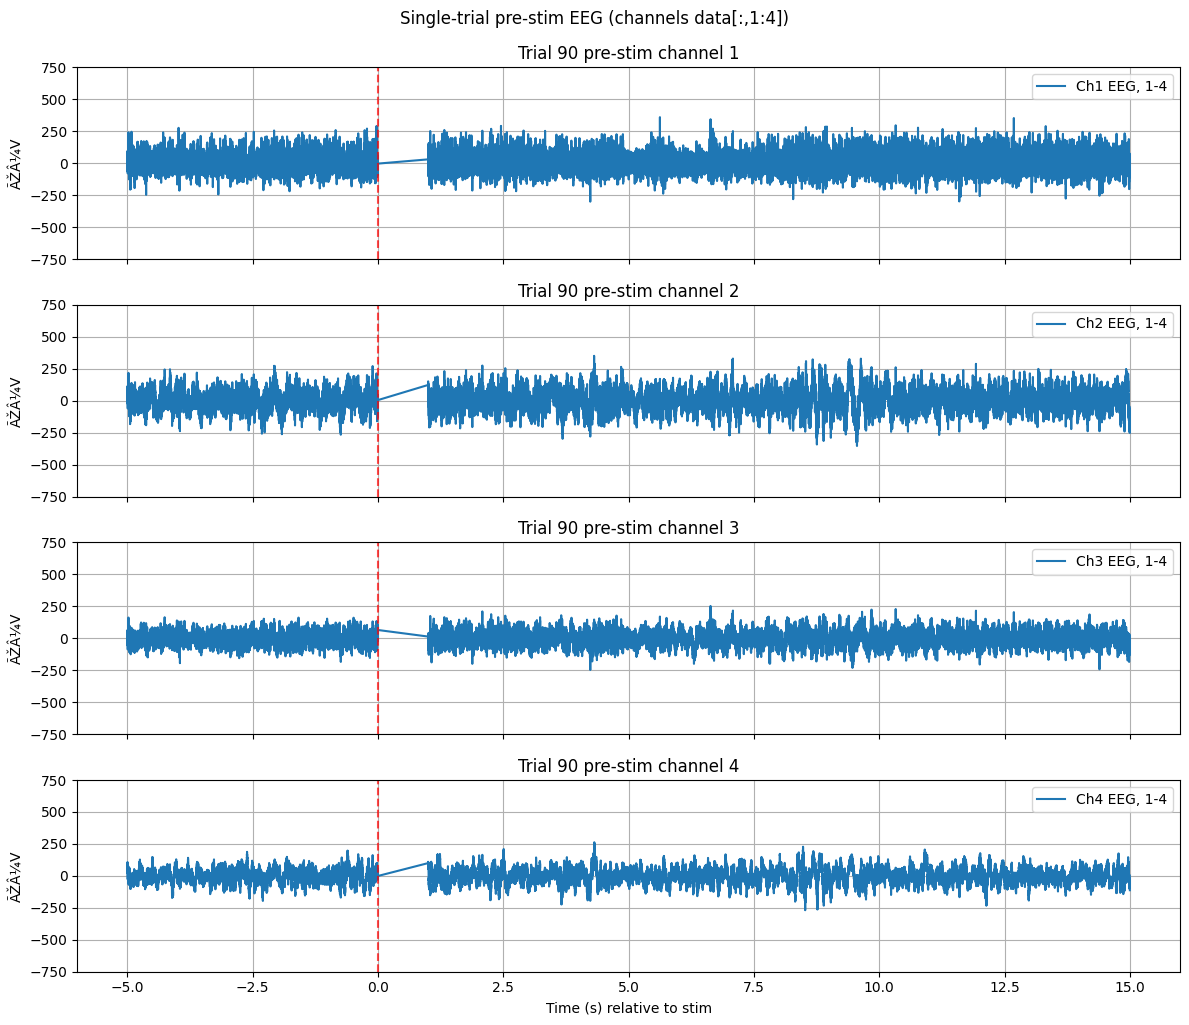

In [12]:
# plots pre_stim eeg data, Duplicate all_trials and extract only channels 1-4 (5 is omitted since due to how python works)
data_sel = data_diff[:, 1:5]   # only channels 1,2,3 (0-based)
duplicate_trials = all_trials
duplicate_trials = extract_windows(trial_table, timestamps, data_sel)
single_trial_idx = 89   # Select trial index to plot (0-based)
trial = duplicate_trials[single_trial_idx]

pre_t = trial["pre_timestamps"]     # negative values before stim
pre_data = trial["pre_data"]        # shape (n_samples_pre, 3)
post_data = trial["post_data"]      # shape (n_samples_post, 3)
combined_t = np.concatenate((trial["pre_timestamps"], trial["post_timestamps"]))
combined_data = np.vstack((trial["pre_data"], trial["post_data"]))
channels_to_plot = pre_data.shape[1]  # should be 3
fig, axes = plt.subplots(channels_to_plot, 1,
                         figsize=(12, 2.5 * channels_to_plot),
                         sharex=True)

for ch in range(channels_to_plot):
    ax = axes[ch]
    ax.plot(combined_t, combined_data[:, ch], label=f"Ch{ch+1} EEG, 1-4")
    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    ax.set_ylim(-750, 750)
    ax.set_ylabel("ÃŽÂ¼V")
    ax.set_title(f"Trial {trial['trial']} pre-stim channel {ch+1}")
    ax.grid(True)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time (s) relative to stim")
plt.tight_layout()
plt.suptitle(f"Single-trial pre-stim EEG (channels data[:,1:4])", y=1.02)
plt.show()

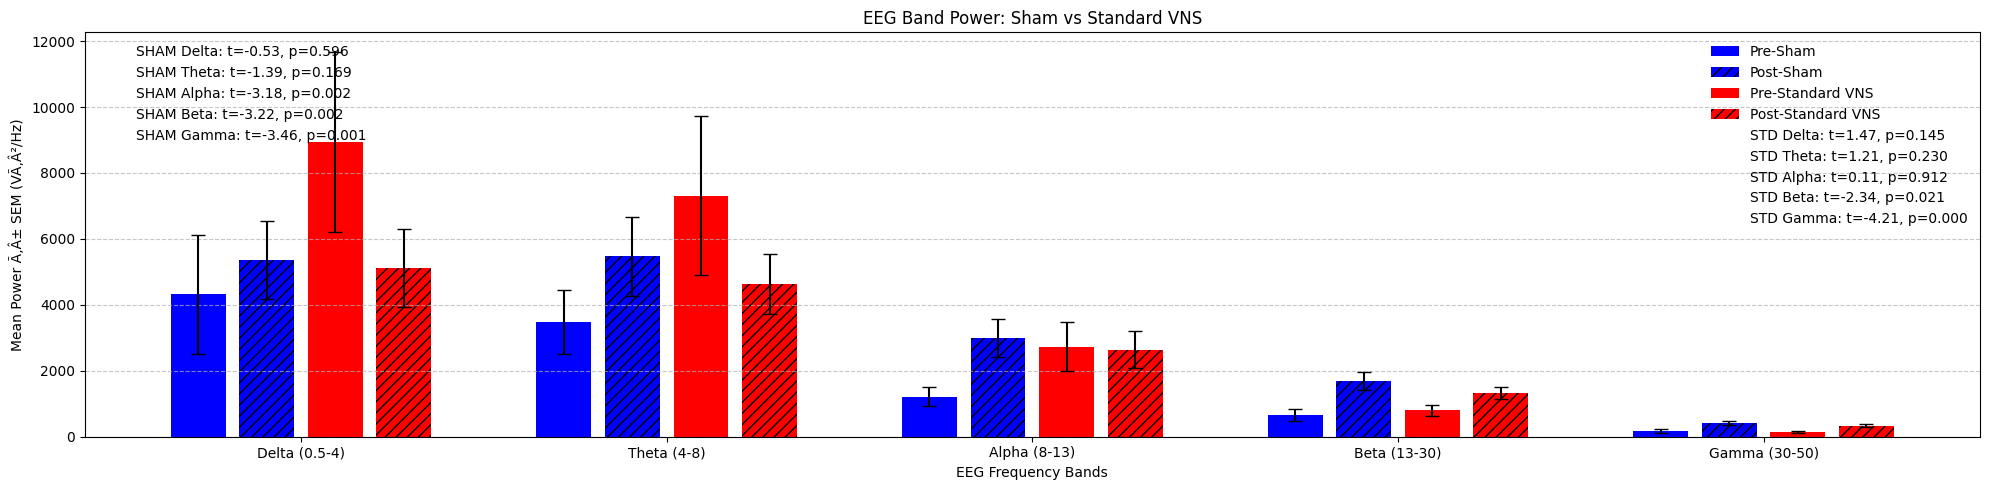

In [13]:
# -----------------------------
# Figure 4: Bar Plot: Mean Band Power Ã‚Â± SEM, PRE VS POST
# -----------------------------

# Seperate df_power dataframe for SHAM and VNS, then calculate means and SEMs 
# for pre and post stimulation for each band and type
bands = list(eeg_bands.keys())
sham_df = df_power[df_power["type"] == "SHAM"]
std_df = df_power[df_power["type"] == "VNS"]

# Group by pre/post mean for each band and type, then grab mean across all trials andreindex to ensure correct order
pre_sham_means = sham_df.groupby("band")["pre_mean"].mean().reindex(bands)
pre_sham_sems = sham_df.groupby("band")["pre_mean"].sem(ddof=0).reindex(bands)
post_sham_means = sham_df.groupby("band")["post_mean"].mean().reindex(bands)
post_sham_sems = sham_df.groupby("band")["post_mean"].sem(ddof=0).reindex(bands)

pre_std_means = std_df.groupby("band")["pre_mean"].mean().reindex(bands)
pre_std_sems = std_df.groupby("band")["pre_mean"].sem(ddof=0).reindex(bands)
post_std_means = std_df.groupby("band")["post_mean"].mean().reindex(bands)
post_std_sems = std_df.groupby("band")["post_mean"].sem(ddof=0).reindex(bands)

# Set up bar plot parameters
x = np.arange(len(bands))
width = 0.15

fig4, ax = plt.subplots(figsize=(20, 5))
ax.bar(x - 15 * width / 8, pre_sham_means, width,
       yerr=pre_sham_sems, capsize=5, label="Pre-Sham", color="blue")
ax.bar(x - 5 * width / 8, post_sham_means, width,
       yerr=post_sham_sems, capsize=5, label="Post-Sham", color="blue", hatch="///")
ax.bar(x + 5 * width / 8, pre_std_means, width,
       yerr=pre_std_sems, capsize=5, label="Pre-Standard VNS", color="red")
ax.bar(x + 15 * width / 8, post_std_means, width,
       yerr=post_std_sems, capsize=5, label="Post-Standard VNS", color="red", hatch="///")

t_stats_std = []
p_vals_std = []
t_stats_sham = []
p_vals_sham = []

# Perform paired t-tests for each band/type and store results for legend
for band in bands:
    pre_std_vals = std_df.loc[std_df["band"] == band, "pre_mean"]
    post_std_vals = std_df.loc[std_df["band"] == band, "post_mean"]
    pre_sham_vals = sham_df.loc[sham_df["band"] == band, "pre_mean"]
    post_sham_vals = sham_df.loc[sham_df["band"] == band, "post_mean"]

    t_stat_std, p_val_std = ttest_rel(pre_std_vals, post_std_vals)
    t_stat_sham, p_val_sham = ttest_rel(pre_sham_vals, post_sham_vals)
    t_stats_std.append(t_stat_std)
    p_vals_std.append(p_val_std)
    t_stats_sham.append(t_stat_sham)
    p_vals_sham.append(p_val_sham)

handle_std = [
    mlines.Line2D([], [], color="none", label=f"STD {band}: t={t:.2f}, p={p:.3f}")
    for band, t, p in zip(bands, t_stats_std, p_vals_std)
]
handle_sham = [
    mlines.Line2D([], [], color="none", label=f"SHAM {band}: t={t:.2f}, p={p:.3f}")
    for band, t, p in zip(bands, t_stats_sham, p_vals_sham)
]

legend_stats_upper_left = ax.legend(handles=handle_sham, loc="upper left", fontsize=10, frameon=False)
ax.add_artist(legend_stats_upper_left)
handles_main, labels_main = ax.get_legend_handles_labels()
handles_main.extend(handle_std)
ax.legend(handles=handles_main, loc="upper right", fontsize=10, frameon=False)

ax.set_xlabel("EEG Frequency Bands")
ax.set_ylabel("Mean Power Ã‚Â± SEM (VÃ‚Â²/Hz)")
ax.set_title("EEG Band Power: Sham vs Standard VNS")
ax.set_xticks(x)
ax.set_xticklabels([
    "Delta (0.5-4)", "Theta (4-8)", "Alpha (8-13)",
    "Beta (13-30)", "Gamma (30-50)"
])
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show(block=False)

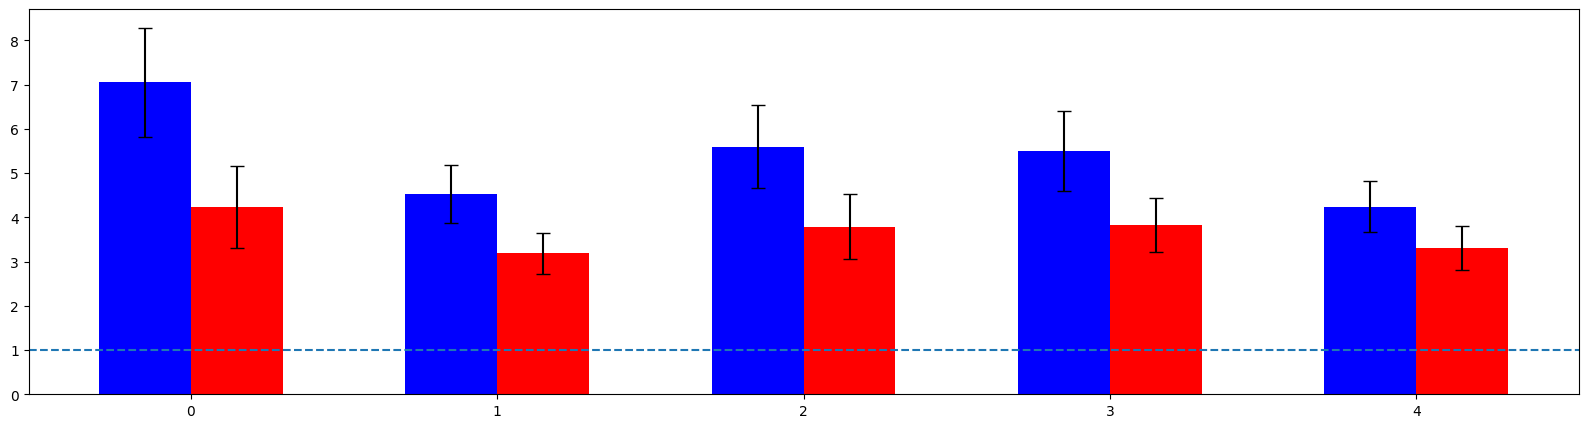

In [14]:
# -----------------------------
# Figure 5: Bar Plot: Mean Band Power Ã‚Â± SEM, PRE VS POST
# -----------------------------

df_power["normalized"] = df_power["post_mean"] / df_power["pre_mean"]

sham_df = df_power[df_power["type"] == "SHAM"]
std_df = df_power[df_power["type"] == "VNS"]

norm_sham_means = sham_df.groupby("band")["normalized"].mean().reindex(bands)
norm_sham_sems = sham_df.groupby("band")["normalized"].sem(ddof=0).reindex(bands)

norm_std_means = std_df.groupby("band")["normalized"].mean().reindex(bands)
norm_std_sems = std_df.groupby("band")["normalized"].sem(ddof=0).reindex(bands)

x = np.arange(len(bands))
width = 0.3

fig, ax = plt.subplots(figsize=(20,5))

ax.bar(x - width/2,
       norm_sham_means,
       width,
       yerr=norm_sham_sems,
       capsize=5,
       label="Sham",
       color="blue")

ax.bar(x + width/2,
       norm_std_means,
       width,
       yerr=norm_std_sems,
       capsize=5,
       label="Standard VNS",
       color="red")

ax.axhline(1, linestyle='--')

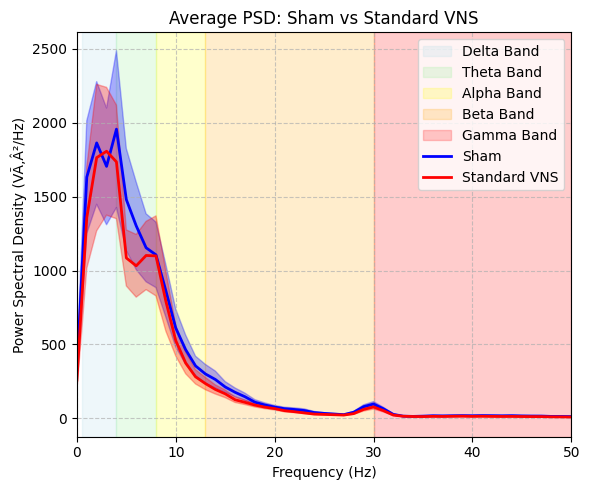

In [15]:
# -----------------------------
# Figure 6: Bar Plot: Average PSD Sham vs Standard VNS
# -----------------------------
# Helper: compute average PSD and SEM for a trial group
def mean_sem_group_psd(group, phase):
    stack = np.array([
        np.mean(np.vstack(trial[f"{phase}_psd"]), axis=0)
        for trial in group
    ])
    return np.mean(stack, axis=0), sem(stack, axis=0, nan_policy="omit")

post_sham_mean_psd, post_sham_sem_psd = mean_sem_group_psd(sham_trials, "post")
post_std_mean_psd, post_std_sem_psd = mean_sem_group_psd(std_trials, "post")

frequencies = (
    sham_trials[0]["post_freqs"][0]
    if len(sham_trials) > 0 else std_trials[0]["post_freqs"][0]
)

fig6, ax = plt.subplots(figsize=(6, 5))

# Shade EEG bands in the PSD plot
band_colors = {
    "Delta": "lightblue",
    "Theta": "lightgreen",
    "Alpha": "yellow",
    "Beta": "orange",
    "Gamma": "red",
}
for band, (low, high) in eeg_bands.items():
    ax.axvspan(low, high, color=band_colors[band], alpha=0.2, label=f"{band} Band")

ax.plot(frequencies, post_sham_mean_psd, color="blue", label="Sham", linewidth=2)
ax.fill_between(frequencies,
                post_sham_mean_psd - post_sham_sem_psd,
                post_sham_mean_psd + post_sham_sem_psd,
                color="blue", alpha=0.3)
ax.plot(frequencies, post_std_mean_psd, color="red", label="Standard VNS", linewidth=2)
ax.fill_between(frequencies,
                post_std_mean_psd - post_std_sem_psd,
                post_std_mean_psd + post_std_sem_psd,
                color="red", alpha=0.3)

ax.set_xlim([0, 50])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (VÃ‚Â²/Hz)")
ax.set_title("Average PSD: Sham vs Standard VNS")
ax.legend(loc="upper right", fontsize=10)
ax.grid(linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show(block=False)

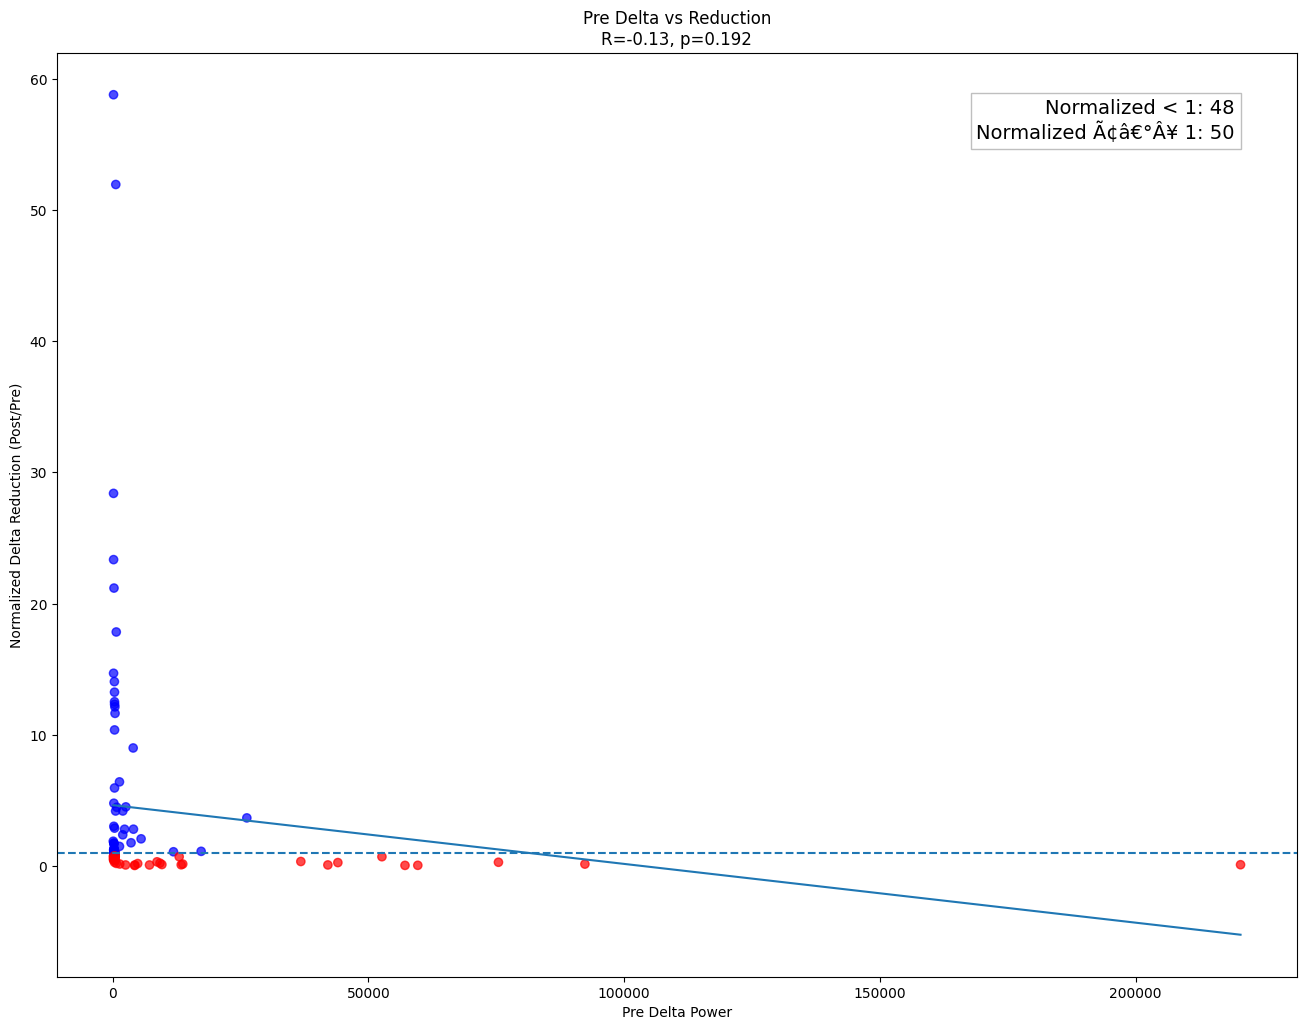

In [16]:

# -----------------------------
# Figure 8: Linear Regression Scatter Plot of Pre Delta vs Normalized Delta Reduction
# -----------------------------

# Extract values for scatter plot of pre delta vs normalized delta reduction
x = np.array([trial["pre_band_mean"]["Delta"] for trial in std_trials])
y = np.array([
    trial["post_band_mean"]["Delta"] / trial["pre_band_mean"]["Delta"]
    for trial in std_trials
])

# Linear regression
slope, intercept, r, p, stderr = linregress(x, y)

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

# Determine colors: red if normalized < 1, blue otherwise
colors = ['red' if val < 1 else 'blue' for val in y]

# Count how many below and above 1
num_below = np.sum(y < 1)
num_above = np.sum(y >= 1)

# Plot
plt.figure(figsize=(16,12))

plt.scatter(x, y, c=colors, alpha=0.7)
plt.plot(x_line, y_line)

plt.axhline(1, linestyle='--')

plt.xlabel("Pre Delta Power")
plt.ylabel("Normalized Delta Reduction (Post/Pre)")
plt.title(f"Pre Delta vs Reduction\nR={r:.2f}, p={p:.3f}")

plt.text(
    0.95, 0.95,
    f'Normalized < 1: {num_below}\nNormalized Ã¢â€°Â¥ 1: {num_above}',
    horizontalalignment='right',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    fontsize=14,
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray')
)

plt.show()

In [17]:
trial_idx = 11  # Select trial index to analyze (0-based)

samples_per_sec = int(samplerate)

trial = all_trials[trial_idx]  # your single trial

trial_features = {
    "pre": [],
    "post": []
}

for phase in ("pre", "post"):
    d = trial[f"{phase}_data"]  # (time, channels)

    for start in range(0, d.shape[0], samples_per_sec):
        window = d[start:start + samples_per_sec]

        if window.shape[0] < samples_per_sec:
            continue

        window_result = {
            "freqs": [],
            "psd": [],
            "band_power": []
        }

        for ch_idx in range(window.shape[1]):
            ch = window[:, ch_idx]

            freqs, psd = signal.welch(
                ch,
                fs=samplerate,
                nperseg=samples_per_sec,
                detrend="constant"
            )

            window_result["freqs"].append(freqs)
            window_result["psd"].append(psd)

            band_power = {}
            for band, (low, high) in eeg_bands.items():
                idx = np.logical_and(freqs >= low, freqs <= high)
                band_power[band] = trapz(psd[idx], freqs[idx])

            window_result["band_power"].append(band_power)

        trial_features[phase].append(window_result)

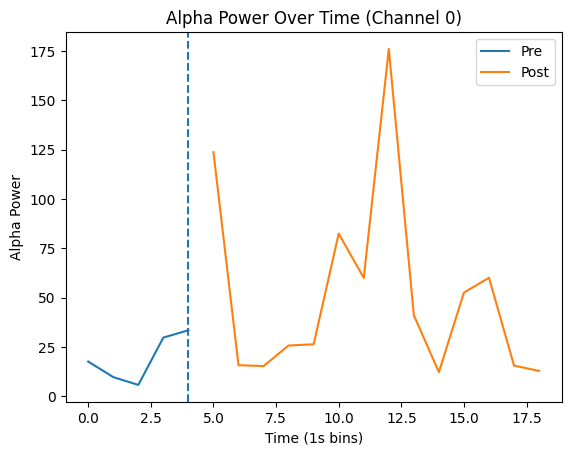

In [18]:
# AFTER-BEFORE/befor to make it % and normalize to look at difference in change
# Wilcoxon for non parametric distributin. mixed model analysis
# baseline correciton: grab mean of pre then subtract it all from stim to post end to see change from baseline.
# waveleet eeg \\\pli and wpli
# EEG data human > data anylsis >codes, pythonmne
# plot all channels opacity thingy to look at
band = "Delta"
ch = 1

pre_alpha = [
    window["band_power"][ch][band]
    for window in trial_features["pre"]
]

post_alpha = [
    window["band_power"][ch][band]
    for window in trial_features["post"]
]

pre_time = np.arange(len(pre_alpha))
post_time = np.arange(len(post_alpha)) + len(pre_alpha)

plt.figure()
plt.plot(pre_time, pre_alpha, label="Pre")
plt.plot(post_time, post_alpha, label="Post")

plt.axvline(len(pre_alpha)-1, linestyle="--")

plt.xlabel("Time (1s bins)")
plt.ylabel("Alpha Power")
plt.title("Alpha Power Over Time (Channel 0)")
plt.legend()
plt.show()

In [19]:
# -----------------------------
# Figure 10: Interactive Trial Viewer
# 5 EEG channels (incl. ref) + averaged-across-channels signal, per trial
# Data shown is post-pipeline (notch + high-pass + ref subtraction).
# Optional |signal| rectification is applied AFTER all filtering, at plot time.
# X-axis units toggle between seconds and milliseconds.
# Layout: 3 rows x 2 columns grid, OR single-panel fullscreen via the Focus dropdown.
# Stim-end (red overlay end) can be auto (= stimulation_duration) or set manually.
# Pre-VNS / Post-VNS analysis windows are drawn on each panel and used to
# compute PSDs shown in a second 3x2 grid below the trial viewer.
# Second figure can show PSD (V^2/Hz) or Power (V^2) per frequency bin,
# with auto or manual y-axis ranges.
# -----------------------------
from ipywidgets import (Button, Output, HBox, VBox, Dropdown,
                        Checkbox, ToggleButton, FloatText, HTML, Label)
from IPython.display import display

# Data column layout (see preprocessing cell):
#   1: EEG, 2: Electrode 1, 3: Electrode 2, 4: Electrode 3, 5: Electrode 4 (ref)
_eeg_cols     = [1, 2, 3, 4, 5]
_eeg_labels   = ['EEG', 'Electrode 1', 'Electrode 2', 'Electrode 3', 'Electrode 4 (ref)']
_panel_labels = _eeg_labels + ['Avg of 5 channels']  # 6 panels: 5 channels + average

# Band shading (matches Figure 6's visual language)
_band_colors = {
    "Delta": "lightblue",
    "Theta": "lightgreen",
    "Alpha": "yellow",
    "Beta":  "orange",
    "Gamma": "red",
}

_n_trials = len(all_trials)
# All time-related state values are stored in SECONDS internally.
# FloatText widgets show them in the currently selected display units (s or ms).
_state = {
    'idx': 0,
    'rectify': False,
    'auto_x': True,
    'auto_y': True,
    'auto_stim': False,
    'units': 's',
    'x_min': -5.0,
    'x_max': 15.0,
    'y_min': -500.0,
    'y_max':  500.0,
    'stim_end':   0.5,                          # seconds (default = 500 ms)
    'pre_start':  -2.0,                          # seconds
    'pre_end':     0.0,                          # seconds
    'post_start': 0.5,                           # seconds; defaults to stim end (500 ms)
    'post_end':    2.75,                         # seconds
    'focus': -1,                                 # -1 = grid; 0..4 = channel; 5 = avg
    # Second-figure (PSD/Power) controls
    'psd_mode': 'PSD',         # 'PSD' (V^2/Hz) or 'Power' (V^2)
    'auto_psd_y': True,
    'psd_y_min': 0.0,
    'psd_y_max': 1.0,
}
_trial_out = Output()
_psd_out   = Output()


def _unit_factor(units):
    return 1000.0 if units == 'ms' else 1.0


def _set_box_silently(box, observer, value):
    box.unobserve(observer, names='value')
    box.value = float(value)
    box.observe(observer, names='value')


def _window_indicator(ax, t_start_disp, t_end_disp, color, y_lim):
    """Draw a thick horizontal bar near the bottom of `ax` indicating a window."""
    if t_start_disp >= t_end_disp:
        return
    y_bot = y_lim[0] + 0.04 * (y_lim[1] - y_lim[0])
    ax.hlines(y_bot, t_start_disp, t_end_disp, color=color, linewidth=4, alpha=0.9)


def _draw_panel(ax, t_disp, y_data, title, units, stim_end_disp,
                x_lim, y_lim, pre_disp, post_disp,
                color='C0', linewidth=0.7):
    ax.plot(t_disp, y_data, color=color, linewidth=linewidth)
    ax.axvspan(0, stim_end_disp, color='red', alpha=0.10)
    ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.8)
    ax.axvline(stim_end_disp, color='red', linestyle='--', linewidth=1, alpha=0.8)
    # Pre-VNS (dark blue) and Post-VNS (dark red) window indicators
    _window_indicator(ax, pre_disp[0],  pre_disp[1],  'darkblue', y_lim)
    _window_indicator(ax, post_disp[0], post_disp[1], 'darkred',  y_lim)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(f'Time({units})', fontsize=20)
    ax.set_ylabel('μV', fontsize=22)
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)


def _compute_psd(data, fs):
    """PSD via spectrogram so we can get a per-segment SEM band.
    Returns (freqs, mean_PSD, sem_PSD, df) where df is the bin width in Hz."""
    n = len(data)
    if n < 16:
        return None, None, None, None
    nperseg  = min(int(fs), n)            # ~1-second segments where possible
    noverlap = nperseg // 2 if nperseg > 1 else 0
    f, _, Sxx = signal.spectrogram(data, fs=fs, nperseg=nperseg,
                                   noverlap=noverlap, detrend='constant',
                                   scaling='density')
    if Sxx.shape[1] == 0:
        return None, None, None, None
    psd_mean = np.mean(Sxx, axis=1)
    psd_sem  = (sem(Sxx, axis=1, nan_policy='omit')
                if Sxx.shape[1] >= 2 else np.zeros_like(psd_mean))
    df = float(f[1] - f[0]) if len(f) >= 2 else 1.0
    return f, psd_mean, psd_sem, df


def _draw_psd_panel(ax, f_pre, m_pre, s_pre, f_post, m_post, s_post,
                    title, ylabel, y_lim):
    """Draw a single PSD/Power panel from pre-computed mean/sem arrays."""
    # Band shading (same overlay style as Figure 6)
    for band, (low, high) in eeg_bands.items():
        ax.axvspan(low, high, color=_band_colors[band], alpha=0.2,
                   label=f"{band} Band")

    if f_pre is not None:
        ax.plot(f_pre, m_pre, color='darkblue', linewidth=2, label='Pre-VNS')
        ax.fill_between(f_pre, m_pre - s_pre, m_pre + s_pre,
                        color='darkblue', alpha=0.3)
    if f_post is not None:
        ax.plot(f_post, m_post, color='darkred', linewidth=2, label='Post-VNS')
        ax.fill_between(f_post, m_post - s_post, m_post + s_post,
                        color='darkred', alpha=0.3)

    ax.set_xlim([0, 50])
    ax.set_ylim(y_lim)
    ax.set_xlabel("Frequency (Hz)", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=18)
    ax.tick_params(labelsize=11)
    ax.grid(linestyle="--", alpha=0.7)


def _dedup_legend(ax, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()
    seen, h2, l2 = set(), [], []
    for h, l in zip(handles, labels):
        if l in seen:
            continue
        seen.add(l); h2.append(h); l2.append(l)
    ax.legend(h2, l2, **legend_kwargs)


def _plot_trial(idx):
    with _trial_out:
        _trial_out.clear_output(wait=True)
        trial  = all_trials[idx]
        units  = _state['units']
        factor = _unit_factor(units)

        t_disp = trial['timestamps'] * factor   # seconds -> displayed unit

        # ---- stim end (auto = stimulation_duration; manual = user value) ----
        if _state['auto_stim']:
            stim_end_internal = float(stimulation_duration)
            _state['stim_end'] = stim_end_internal
            _set_box_silently(_stim_end_box, _on_stim_end,
                              round(stim_end_internal * factor, 4))
        else:
            stim_end_internal = float(_state['stim_end'])
        stim_end_disp = stim_end_internal * factor

        eeg = trial['data'][:, _eeg_cols]      # (n_samples, 5)
        avg = eeg.mean(axis=1)                 # average across the 5 channels

        if _state['rectify']:
            eeg = np.abs(eeg); avg = np.abs(avg)

        # ---- compute auto ranges ----
        auto_x_min = float(t_disp[0]); auto_x_max = float(t_disp[-1])
        all_y = np.concatenate([eeg.flatten(), avg])
        all_y = all_y[~np.isnan(all_y)]
        if len(all_y):
            auto_y_min = float(np.min(all_y))
            auto_y_max = float(np.max(all_y))
            y_pad = max(0.05 * (auto_y_max - auto_y_min), 1.0)
            auto_y_min -= y_pad; auto_y_max += y_pad
        else:
            auto_y_min, auto_y_max = -1.0, 1.0

        if _state['auto_x']:
            _set_box_silently(_xmin_box, _on_xmin, round(auto_x_min, 4))
            _set_box_silently(_xmax_box, _on_xmax, round(auto_x_max, 4))
            _state['x_min'] = auto_x_min; _state['x_max'] = auto_x_max
        if _state['auto_y']:
            _set_box_silently(_ymin_box, _on_ymin, round(auto_y_min, 4))
            _set_box_silently(_ymax_box, _on_ymax, round(auto_y_max, 4))
            _state['y_min'] = auto_y_min; _state['y_max'] = auto_y_max

        x_lim = (_state['x_min'], _state['x_max'])
        y_lim = (_state['y_min'], _state['y_max'])

        pre_disp  = (_state['pre_start']  * factor, _state['pre_end']  * factor)
        post_disp = (_state['post_start'] * factor, _state['post_end'] * factor)

        rec_tag = '  |rectified|' if _state['rectify'] else ''
        focus   = _state['focus']
        suptitle = (f"Trial {trial['trial']} ({trial['type']})  -  "
                    f"filtered, ref-subtracted{rec_tag}   ({idx + 1}/{_n_trials})")

        legend_handles = [
            mlines.Line2D([0], [0], color='darkblue', linewidth=4, label='Pre-VNS window'),
            mlines.Line2D([0], [0], color='darkred',  linewidth=4, label='Post-VNS window'),
        ]

        if focus == -1:
            # ---- 3 rows x 2 cols grid ----
            # sharex/sharey are OFF so every panel keeps its own axis labels and tick labels.
            fig, axes = plt.subplots(3, 2, figsize=(14, 10),
                                     sharex=False, sharey=False)
            axes_flat = axes.flatten()
            for i, label in enumerate(_eeg_labels):
                _draw_panel(axes_flat[i], t_disp, eeg[:, i], label, units,
                            stim_end_disp, x_lim, y_lim, pre_disp, post_disp)
            _draw_panel(axes_flat[5], t_disp, avg, 'Avg of 5 channels', units,
                        stim_end_disp, x_lim, y_lim, pre_disp, post_disp,
                        color='black', linewidth=0.9)
            fig.legend(handles=legend_handles, loc='upper right', ncol=2,
                       fontsize=11, frameon=False, bbox_to_anchor=(0.98, 0.985))
            fig.suptitle(suptitle, fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.96])
        else:
            # ---- single-panel fullscreen view of the focused plot ----
            fig, ax = plt.subplots(figsize=(14, 8))
            if focus < 5:
                y_data, title = eeg[:, focus], _eeg_labels[focus]
                color, lw = 'C0', 0.9
            else:
                y_data, title = avg, 'Avg of 5 channels'
                color, lw = 'black', 1.1
            _draw_panel(ax, t_disp, y_data, title, units,
                        stim_end_disp, x_lim, y_lim, pre_disp, post_disp,
                        color=color, linewidth=lw)
            ax.legend(handles=legend_handles, loc='upper right',
                      fontsize=12, frameon=False)
            fig.suptitle(suptitle, fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.95])

        plt.show()

    # PSD figure refreshes whenever the trial figure does
    _plot_psd(idx)


def _plot_psd(idx):
    with _psd_out:
        _psd_out.clear_output(wait=True)
        trial = all_trials[idx]

        # Time mask is computed on raw trial timestamps (in seconds).
        ts = trial['timestamps']
        ps, pe = _state['pre_start'],  _state['pre_end']
        qs, qe = _state['post_start'], _state['post_end']
        if ps >= pe or qs >= qe:
            print("Pre-VNS or Post-VNS window is empty (start >= end). "
                  "Adjust the window boxes to enable PSD comparison.")
            return
        pre_mask  = (ts >= ps) & (ts < pe)
        post_mask = (ts >= qs) & (ts < qe)
        if pre_mask.sum() < 16 or post_mask.sum() < 16:
            print("Pre-VNS or Post-VNS window has too few samples after intersecting "
                  "with the trial window. Widen the window or pick a different trial.")
            return

        eeg = trial['data'][:, _eeg_cols]
        avg = eeg.mean(axis=1)
        if _state['rectify']:
            eeg = np.abs(eeg); avg = np.abs(avg)

        focus  = _state['focus']
        mode   = _state['psd_mode']         # 'PSD' or 'Power'
        ylabel = ('EEG Power (V²)' if mode == 'Power'
                  else 'EEG Power Density (V²/Hz)')
        units  = _state['units']
        factor = _unit_factor(units)
        suptitle = (f"Pre-VNS vs Post-VNS {mode}  -  Trial {trial['trial']} ({trial['type']})  -  "
                    f"Pre [{ps*factor:.2f}, {pe*factor:.2f}]{units}  /  "
                    f"Post [{qs*factor:.2f}, {qe*factor:.2f}]{units}")

        # Build (signal, title) list for the panels we're going to draw
        if focus == -1:
            panels_in = [(eeg[:, i], lbl) for i, lbl in enumerate(_eeg_labels)]
            panels_in.append((avg, 'Avg of 5 channels'))
        else:
            sig = eeg[:, focus] if focus < 5 else avg
            t   = _eeg_labels[focus] if focus < 5 else 'Avg of 5 channels'
            panels_in = [(sig, t)]

        # Compute PSD/Power for each panel (Power = PSD x df).
        panels_data = []
        for sig, t in panels_in:
            f_pre,  m_pre,  s_pre,  df_pre  = _compute_psd(sig[pre_mask],  samplerate)
            f_post, m_post, s_post, df_post = _compute_psd(sig[post_mask], samplerate)
            if mode == 'Power':
                if m_pre is not None:
                    m_pre  = m_pre  * df_pre;  s_pre  = s_pre  * df_pre
                if m_post is not None:
                    m_post = m_post * df_post; s_post = s_post * df_post
            panels_data.append((f_pre, m_pre, s_pre, f_post, m_post, s_post, t))

        # ---- auto y-range: max across all panels in the visible 0-50 Hz band ----
        tops = []
        for f_pre, m_pre, s_pre, f_post, m_post, s_post, _t in panels_data:
            for f_arr, m_arr, s_arr in [(f_pre, m_pre, s_pre),
                                        (f_post, m_post, s_post)]:
                if f_arr is None:
                    continue
                vis = (f_arr >= 0) & (f_arr <= 50)
                if not vis.any():
                    continue
                tops.append(float(np.nanmax((m_arr + s_arr)[vis])))
        auto_max = (max(tops) * 1.05) if tops else 1.0
        auto_min = 0.0   # PSD/Power are non-negative

        if _state['auto_psd_y']:
            _set_box_silently(_psd_ymin_box, _on_psd_ymin, round(auto_min, 4))
            _set_box_silently(_psd_ymax_box, _on_psd_ymax, round(auto_max, 4))
            _state['psd_y_min'] = auto_min
            _state['psd_y_max'] = auto_max
        y_lim = (_state['psd_y_min'], _state['psd_y_max'])

        if focus == -1:
            fig, axes = plt.subplots(3, 2, figsize=(14, 10),
                                     sharex=False, sharey=False)
            axes_flat = axes.flatten()
            for ax, panel in zip(axes_flat, panels_data):
                f_pre, m_pre, s_pre, f_post, m_post, s_post, t = panel
                _draw_psd_panel(ax, f_pre, m_pre, s_pre, f_post, m_post, s_post,
                                t, ylabel, y_lim)
                _dedup_legend(ax, loc='upper right',
                              fontsize=9, frameon=False)
            fig.suptitle(suptitle, fontsize=15)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
        else:
            fig, ax = plt.subplots(figsize=(14, 8))
            f_pre, m_pre, s_pre, f_post, m_post, s_post, t = panels_data[0]
            _draw_psd_panel(ax, f_pre, m_pre, s_pre, f_post, m_post, s_post,
                            t, ylabel, y_lim)
            _dedup_legend(ax, loc='upper right', fontsize=12, frameon=False)
            fig.suptitle(suptitle, fontsize=15)
            plt.tight_layout(rect=[0, 0, 1, 0.95])

        plt.show()


# ---- navigation handlers ----
def _on_prev(b):
    new_idx = max(_state['idx'] - 1, 0)
    if new_idx != _state['idx']:
        _trial_drop.value = new_idx     # triggers observer

def _on_next(b):
    new_idx = min(_state['idx'] + 1, _n_trials - 1)
    if new_idx != _state['idx']:
        _trial_drop.value = new_idx     # triggers observer

def _on_trial_change(change):
    if change['name'] == 'value':
        _state['idx'] = int(change['new'])
        _plot_trial(_state['idx'])

def _on_focus(change):
    if change['name'] == 'value':
        _state['focus'] = int(change['new'])
        _plot_trial(_state['idx'])


# ---- option handlers ----
def _on_rectify(change):
    _state['rectify'] = bool(change['new'])
    _plot_trial(_state['idx'])

def _on_units(change):
    new_units = 'ms' if change['new'] else 's'
    if new_units == _state['units']:
        return
    # Convert manual x-range values so the visual zoom stays the same.
    old_f = _unit_factor(_state['units'])
    new_f = _unit_factor(new_units)
    conv  = new_f / old_f
    _state['x_min'] *= conv
    _state['x_max'] *= conv
    _state['units']  = new_units
    _units_toggle.description   = f'X-axis: {new_units}'
    _xmin_box.description       = f'X min ({new_units}):'
    _xmax_box.description       = f'X max ({new_units}):'
    _stim_end_box.description   = f'Stim end ({new_units}):'
    _pre_start_box.description  = f'Pre start ({new_units}):'
    _pre_end_box.description    = f'Pre end ({new_units}):'
    _post_start_box.description = f'Post start ({new_units}):'
    _post_end_box.description   = f'Post end ({new_units}):'
    # Internal time-state stays in seconds; refresh on-screen values in the new unit.
    _set_box_silently(_stim_end_box,   _on_stim_end,   round(_state['stim_end']   * new_f, 4))
    _set_box_silently(_pre_start_box,  _on_pre_start,  round(_state['pre_start']  * new_f, 4))
    _set_box_silently(_pre_end_box,    _on_pre_end,    round(_state['pre_end']    * new_f, 4))
    _set_box_silently(_post_start_box, _on_post_start, round(_state['post_start'] * new_f, 4))
    _set_box_silently(_post_end_box,   _on_post_end,   round(_state['post_end']   * new_f, 4))
    _plot_trial(_state['idx'])

def _on_auto_x(change):
    _state['auto_x'] = bool(change['new'])
    _xmin_box.disabled = bool(change['new'])
    _xmax_box.disabled = bool(change['new'])
    _auto_x_toggle.description = 'Auto x-scale' if change['new'] else 'Manual x-scale'
    _plot_trial(_state['idx'])

def _on_auto_y(change):
    _state['auto_y'] = bool(change['new'])
    _ymin_box.disabled = bool(change['new'])
    _ymax_box.disabled = bool(change['new'])
    _auto_y_toggle.description = 'Auto y-scale' if change['new'] else 'Manual y-scale'
    _plot_trial(_state['idx'])

def _on_auto_stim(change):
    _state['auto_stim'] = bool(change['new'])
    _stim_end_box.disabled = bool(change['new'])
    _auto_stim_toggle.description = 'Auto stim end' if change['new'] else 'Manual stim end'
    _plot_trial(_state['idx'])

def _on_xmin(change):
    _state['x_min'] = float(change['new'])
    if not _state['auto_x']:
        _plot_trial(_state['idx'])

def _on_xmax(change):
    _state['x_max'] = float(change['new'])
    if not _state['auto_x']:
        _plot_trial(_state['idx'])

def _on_ymin(change):
    _state['y_min'] = float(change['new'])
    if not _state['auto_y']:
        _plot_trial(_state['idx'])

def _on_ymax(change):
    _state['y_max'] = float(change['new'])
    if not _state['auto_y']:
        _plot_trial(_state['idx'])

def _on_stim_end(change):
    factor = _unit_factor(_state['units'])
    _state['stim_end'] = float(change['new']) / factor
    if not _state['auto_stim']:
        _plot_trial(_state['idx'])

def _on_pre_start(change):
    _state['pre_start'] = float(change['new']) / _unit_factor(_state['units'])
    _plot_trial(_state['idx'])

def _on_pre_end(change):
    _state['pre_end'] = float(change['new']) / _unit_factor(_state['units'])
    _plot_trial(_state['idx'])

def _on_post_start(change):
    _state['post_start'] = float(change['new']) / _unit_factor(_state['units'])
    _plot_trial(_state['idx'])

def _on_post_end(change):
    _state['post_end'] = float(change['new']) / _unit_factor(_state['units'])
    _plot_trial(_state['idx'])

# Second-figure (PSD/Power) handlers - these only affect the PSD figure,
# so they call _plot_psd directly (skipping the trial-figure redraw).
def _on_psd_mode(change):
    _state['psd_mode'] = 'Power' if change['new'] else 'PSD'
    _psd_mode_toggle.description = f"Mode: {_state['psd_mode']}"
    _plot_psd(_state['idx'])

def _on_auto_psd_y(change):
    _state['auto_psd_y'] = bool(change['new'])
    _psd_ymin_box.disabled = bool(change['new'])
    _psd_ymax_box.disabled = bool(change['new'])
    _auto_psd_y_toggle.description = ('Auto y-scale (PSD)' if change['new']
                                      else 'Manual y-scale (PSD)')
    _plot_psd(_state['idx'])

def _on_psd_ymin(change):
    _state['psd_y_min'] = float(change['new'])
    if not _state['auto_psd_y']:
        _plot_psd(_state['idx'])

def _on_psd_ymax(change):
    _state['psd_y_max'] = float(change['new'])
    if not _state['auto_psd_y']:
        _plot_psd(_state['idx'])


# ---- widgets ----
_prev_btn = Button(description='Prev', button_style='')
_next_btn = Button(description='Next', button_style='primary')
_trial_drop = Dropdown(
    options=[
        (f"Trial {tr['trial']:>3d}  ({tr['type']})", i)
        for i, tr in enumerate(all_trials)
    ],
    value=0,
    description='Trial:',
    layout={'width': '260px'},
)
_focus_drop = Dropdown(
    options=[('Grid (all 6)', -1)] + [(lbl, i) for i, lbl in enumerate(_panel_labels)],
    value=-1,
    description='Focus:',
    layout={'width': '260px'},
)

_rectify_cb = Checkbox(value=False, description='Rectify (|signal|)',
                       indent=False, layout={'width': '200px'})

_units_toggle = ToggleButton(
    value=False, description='X-axis: s', button_style='info',
    tooltip='Toggle x-axis units between seconds (off) and milliseconds (on).',
    layout={'width': '140px'},
)
_auto_x_toggle = ToggleButton(
    value=True, description='Auto x-scale', button_style='success',
    tooltip='When on, x-axis auto-scales to the trial window. When off, uses manual values.',
    layout={'width': '160px'},
)
_auto_y_toggle = ToggleButton(
    value=True, description='Auto y-scale', button_style='success',
    tooltip='When on, y-axis auto-scales to the visible signal. When off, uses manual values.',
    layout={'width': '160px'},
)
_auto_stim_toggle = ToggleButton(
    value=False, description='Manual stim end', button_style='success',
    tooltip=('When on, the red overlay ends at stimulation_duration. '
             'When off, you set where the overlay ends.'),
    layout={'width': '160px'},
)

_u = _state['units']
_xmin_box = FloatText(value=_state['x_min'], description=f"X min ({_u}):",
                      disabled=True, layout={'width': '170px'})
_xmax_box = FloatText(value=_state['x_max'], description=f"X max ({_u}):",
                      disabled=True, layout={'width': '170px'})
_ymin_box = FloatText(value=_state['y_min'], description='Y min:',
                      disabled=True, layout={'width': '155px'})
_ymax_box = FloatText(value=_state['y_max'], description='Y max:',
                      disabled=True, layout={'width': '155px'})
_stim_end_box = FloatText(
    value=_state['stim_end'] * _unit_factor(_u),
    description=f"Stim end ({_u}):",
    disabled=False, layout={'width': '180px'},
)

_pre_start_box  = FloatText(value=_state['pre_start']  * _unit_factor(_u),
                            description=f"Pre start ({_u}):",
                            layout={'width': '180px'})
_pre_end_box    = FloatText(value=_state['pre_end']    * _unit_factor(_u),
                            description=f"Pre end ({_u}):",
                            layout={'width': '180px'})
_post_start_box = FloatText(value=_state['post_start'] * _unit_factor(_u),
                            description=f"Post start ({_u}):",
                            layout={'width': '180px'})
_post_end_box   = FloatText(value=_state['post_end']   * _unit_factor(_u),
                            description=f"Post end ({_u}):",
                            layout={'width': '180px'})

# Second-figure controls
_psd_mode_toggle = ToggleButton(
    value=False, description='Mode: PSD', button_style='info',
    tooltip=('Toggle the second figure between PSD (V²/Hz) and Power (V²) per '
             'frequency bin. Power = PSD x frequency-bin width.'),
    layout={'width': '160px'},
)
_auto_psd_y_toggle = ToggleButton(
    value=True, description='Auto y-scale (PSD)', button_style='success',
    tooltip=('When on, PSD/Power y-axis auto-scales across all panels. '
             'When off, uses the manual values below.'),
    layout={'width': '180px'},
)
_psd_ymin_box = FloatText(value=_state['psd_y_min'], description='PSD Y min:',
                          disabled=True, layout={'width': '170px'})
_psd_ymax_box = FloatText(value=_state['psd_y_max'], description='PSD Y max:',
                          disabled=True, layout={'width': '170px'})

_prev_btn.on_click(_on_prev)
_next_btn.on_click(_on_next)
_trial_drop.observe(_on_trial_change, names='value')
_focus_drop.observe(_on_focus, names='value')

_rectify_cb.observe(_on_rectify, names='value')
_units_toggle.observe(_on_units, names='value')
_auto_x_toggle.observe(_on_auto_x, names='value')
_auto_y_toggle.observe(_on_auto_y, names='value')
_auto_stim_toggle.observe(_on_auto_stim, names='value')
_xmin_box.observe(_on_xmin, names='value')
_xmax_box.observe(_on_xmax, names='value')
_ymin_box.observe(_on_ymin, names='value')
_ymax_box.observe(_on_ymax, names='value')
_stim_end_box.observe(_on_stim_end, names='value')
_pre_start_box.observe(_on_pre_start, names='value')
_pre_end_box.observe(_on_pre_end, names='value')
_post_start_box.observe(_on_post_start, names='value')
_post_end_box.observe(_on_post_end, names='value')
_psd_mode_toggle.observe(_on_psd_mode, names='value')
_auto_psd_y_toggle.observe(_on_auto_psd_y, names='value')
_psd_ymin_box.observe(_on_psd_ymin, names='value')
_psd_ymax_box.observe(_on_psd_ymax, names='value')

_nav_row = HBox([_prev_btn, _next_btn, _trial_drop, _focus_drop,
                 Label('  '), _rectify_cb, _units_toggle])
_axis_row = VBox([
    HTML('<b>Axis controls</b>  (boxes show current auto-scaled values; toggle off to edit)'),
    HBox([_auto_x_toggle,    _xmin_box, _xmax_box]),
    HBox([_auto_y_toggle,    _ymin_box, _ymax_box]),
    HBox([_auto_stim_toggle, _stim_end_box]),
])
_window_row = VBox([
    HTML('<b>PSD analysis windows</b>  '
         '(Pre-VNS = dark blue, Post-VNS = dark red; values in current units)'),
    HBox([Label('Pre-VNS:'),  _pre_start_box,  _pre_end_box]),
    HBox([Label('Post-VNS:'), _post_start_box, _post_end_box]),
])
_psd_row = VBox([
    HTML('<b>PSD figure controls</b>  '
         '(switch between PSD and Power, set y-axis range for the second figure)'),
    HBox([_psd_mode_toggle, _auto_psd_y_toggle, _psd_ymin_box, _psd_ymax_box]),
])

print(f"Loaded {_n_trials} trials. Use Prev/Next or the dropdown to navigate.")
display(VBox([_nav_row, _axis_row, _window_row, _psd_row, _trial_out, _psd_out]))
_plot_trial(0)


Loaded 199 trials. Use Prev/Next or the dropdown to navigate.
